In [1]:
! pip install -r requirements.txt


[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [3]:
# Load data
data = pd.read_csv("tea_data.csv")


In [4]:
# Log transformation (Cobb-Douglas)
data["log_output"] = np.log(data["output"])
data["log_land"] = np.log(data["land"])
data["log_labor"] = np.log(data["labor"])
data["log_fertilizer"] = np.log(data["fertilizer"])

In [5]:
# Define model
X = data[["log_land", "log_labor", "log_fertilizer"]]
X = sm.add_constant(X)
y = data["log_output"]

In [7]:
print (X)

    const  log_land  log_labor  log_fertilizer
0     1.0  0.916291   2.484907        3.218876
1     1.0  1.098612   2.639057        3.332205
2     1.0  1.163151   2.708050        3.401197
3     1.0  1.252763   2.772589        3.465736
4     1.0  1.386294   2.890372        3.555348
5     1.0  1.435085   2.995732        3.637586
6     1.0  1.131402   2.564949        3.295837
7     1.0  1.193922   2.708050        3.367296
8     1.0  1.280934   2.833213        3.496508
9     1.0  1.360977   2.890372        3.583519
10    1.0  1.029619   2.564949        3.258097
11    1.0  1.098612   2.639057        3.332205
12    1.0  1.223775   2.772589        3.433987
13    1.0  1.308333   2.833213        3.526361
14    1.0  1.410987   2.944439        3.610918
15    1.0  1.458615   3.044522        3.663562
16    1.0  1.504077   3.091042        3.688879
17    1.0  1.609438   3.178054        3.806662
18    1.0  1.648659   3.218876        3.871201
19    1.0  1.704748   3.295837        3.912023


In [8]:
print(y)

0     4.787492
1     4.905275
2     5.010635
3     5.075174
4     5.135798
5     5.192957
6     4.941642
7     5.043425
8     5.105945
9     5.164786
10    4.867534
11    4.976734
12    5.062595
13    5.123964
14    5.181784
15    5.204007
16    5.247024
17    5.298317
18    5.347108
19    5.393628
Name: log_output, dtype: float64


In [6]:
# Fit model
model = sm.OLS(y, X).fit()


In [9]:
# Print regression results
print("\n=== REGRESSION RESULTS ===")
print(model.summary())


=== REGRESSION RESULTS ===
                            OLS Regression Results                            
Dep. Variable:             log_output   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     264.8
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           7.64e-14
Time:                        13:01:08   Log-Likelihood:                 48.098
No. Observations:                  20   AIC:                            -88.20
Df Residuals:                      16   BIC:                            -84.21
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           

In [10]:
# Efficiency approximation
data["efficiency"] = np.exp(model.resid)


In [11]:
print("\n=== EFFICIENCY RESULTS ===")
print(data[["output", "efficiency"]])


=== EFFICIENCY RESULTS ===
    output  efficiency
0      120    0.978400
1      135    0.960156
2      150    1.017534
3      160    1.016545
4      170    0.977349
5      180    0.996357
6      140    0.975575
7      155    1.025490
8      165    1.024306
9      175    1.027027
10     130    0.972570
11     145    1.031278
12     158    1.022675
13     168    1.024750
14     178    1.004930
15     182    0.988295
16     190    0.996280
17     200    0.973235
18     210    0.994773
19     220    0.997240


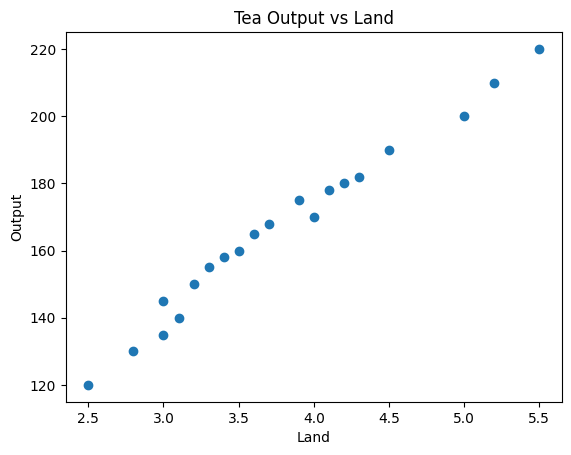

In [12]:
# -----------------------------
# 📊 VISUALIZATIONS (CREATIVITY BOOST)
# -----------------------------

# 1. Output vs Land
plt.figure()
plt.scatter(data["land"], data["output"])
plt.xlabel("Land")
plt.ylabel("Output")
plt.title("Tea Output vs Land")
plt.show()


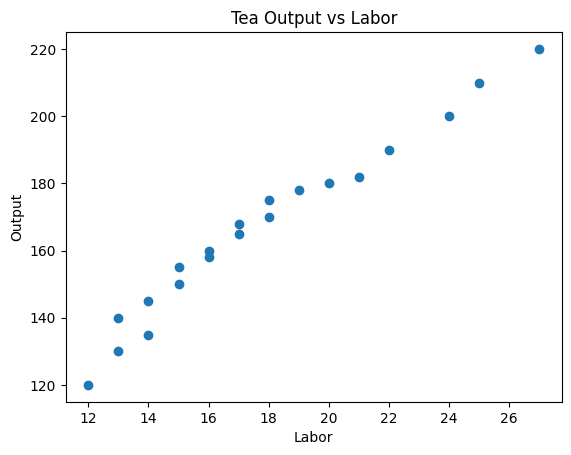

In [13]:
# 2. Output vs Labor
plt.figure()
plt.scatter(data["labor"], data["output"])
plt.xlabel("Labor")
plt.ylabel("Output")
plt.title("Tea Output vs Labor")
plt.show()

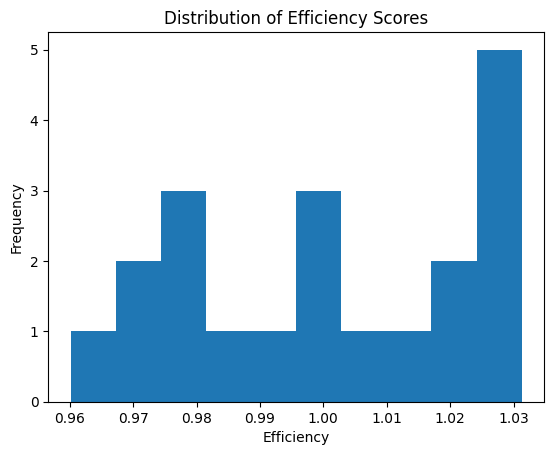

In [14]:
# 3. Efficiency Distribution
plt.figure()
plt.hist(data["efficiency"])
plt.xlabel("Efficiency")
plt.ylabel("Frequency")
plt.title("Distribution of Efficiency Scores")
plt.show()

In [15]:
# -----------------------------
# 📘 INTERPRETATION
# -----------------------------
print("\n=== INTERPRETATION ===")
print("The results show that land, labor, and fertilizer positively influence tea output.")
print("Efficiency scores indicate how close each farm is to optimal production.")
print("Values closer to 1 suggest higher efficiency.")



=== INTERPRETATION ===
The results show that land, labor, and fertilizer positively influence tea output.
Efficiency scores indicate how close each farm is to optimal production.
Values closer to 1 suggest higher efficiency.
